# Hidden Markov Models (forcasting weather)

## Importing,Cleaning and Defining Test/Train Split  

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('seattle.csv',)

# Cleaning the data 

# Removing empty cells as this is weather data
df = df.dropna()

# Cleaning wrong date formats  
df['date'] = pd.to_datetime(df['date'],format= 'mixed')

# Defining Training and Testing set , (Cronologically as is the norm with weather data) , Used a 20:80 split
split = int(len(df)*0.8)
data = df[:split]
test = df[split:]

# Handel missing non positive values in Temp
Temp = data['temp_max']
Temp = Temp.dropna()
Temp = Temp[Temp > 0]

print(len(data['temp_max']))

1168


## ADF test for stationarity(For Tempreture)

In [70]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(Temp)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -2.428618417466321
p-value: 0.13382143102112787
Critical Values:
   1%: -3.4360540638753405
   5%: -2.864058725215095
   10%: -2.568111031100567


#### Test Result
- The adf test reveals that that the data is not stationary at the given confidance interval therfore a transformation is required
- Remove the seasonality component given the context of weather data.
- Using a rolling mean of 30 days  $$ T' = T - 1/30 * \sum_{i=1}^n (T_{t-i}) $$ 
- As a result lost the first 30 data point
- Question to look into , what happens when there arent 30 datapoint to caluculate a mean then adjust from?

In [71]:
import numpy as np

TempTransformed = (data['temp_max']-data['temp_max'].rolling(30).mean()) #<- Number of elem
TempTransformed = TempTransformed.dropna() #<- Failed first time as the roling meand gave NaN for the first 30 data points

# Retesting for Stationarity 

result2 = adfuller(TempTransformed)

print("ADF Statistic:", result2[0])
print("p-value:", result2[1])
print("Critical Values:")
for key, value in result2[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -9.650786002902793
p-value: 1.4366698234277682e-16
Critical Values:
   1%: -3.4361296862775528
   5%: -2.8640920853813365
   10%: -2.5681287981237304


#### Test Two Results 
- The data is Stationary significat to 1%> , furthermore for the pupose variation applying a first diffrance transformation.
- The trasnformation has form $$ x _t =  \delta T _t = T_t - T_{t-1} $$

In [72]:
TempTransformed2 = (TempTransformed).diff()
TempTransformed2 = TempTransformed2.dropna()
# Retesing for  Stationarity

result3 = adfuller(TempTransformed2)

print("ADF Statistic:", result3[0])
print("p-value:", result3[1])
print("Critical Values:")
for key, value in result3[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -13.939284311623327
p-value: 4.9254342749910704e-26
Critical Values:
   1%: -3.4361812251221555
   5%: -2.864114820815637
   10%: -2.5681409066817795


## (After developing the model) -> Certain issues arise as a result of transforming the predictions the model gives thefore am un

#### Further improvements on stationarity , no further transformation(except standardisation as a result of the model being a HMM) reqired.

- $$ z_t = (x_t -\mu)/\sigma $$
- Where x_t is the transformed data

ADF Statistic: -2.4286184174662355
p-value: 0.13382143102115113
Critical Values:
   1%: -3.4360540638753405
   5%: -2.864058725215095
   10%: -2.568111031100567


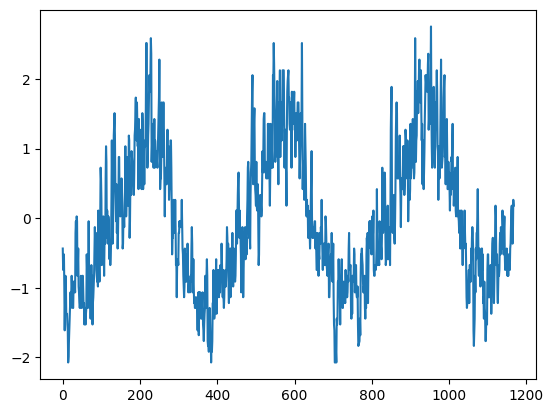

In [73]:
SampleMean = np.mean(Temp)
SampleVariance = np.std(Temp)

StdTemp = (Temp-SampleMean)/SampleVariance
StdTemp = StdTemp.dropna()

plt.plot(StdTemp)
plt.show
result3 = adfuller(StdTemp)
print("ADF Statistic:", result3[0])
print("p-value:", result3[1])
print("Critical Values:")
for key, value in result3[4].items():
    print(f"   {key}: {value}")

## Implemnting the Hidden Markov Model

- The number of states i have chosen is 3 folowing Hot, Cold, Normal regimes 
- Using the hmmlearn package

In [74]:
from hmmlearn.hmm import GaussianHMM

# Define the final time series after transformations
x = StdTemp.values.reshape(-1,1)
# Fitting the HMM

WeatherModel = GaussianHMM(n_components=3,covariance_type="full",n_iter=100)
WeatherModel.fit(x)

# Infering the hidden states and developing the transition matrix
States = WeatherModel.predict(x)
print(States)
print(WeatherModel.transmat_)

# Emission parameters
print(WeatherModel.means_)
print(WeatherModel.covars_)

mu = WeatherModel.means_
sigma = WeatherModel.covars_
 

[0 0 0 ... 1 1 1]
[[9.63900336e-01 3.60996635e-02 2.30372580e-69]
 [3.71573075e-02 9.26329523e-01 3.65131699e-02]
 [1.58087199e-95 2.79781184e-02 9.72021882e-01]]
[[-1.02634087]
 [-0.24667841]
 [ 1.0652597 ]]
[[[0.14636382]]

 [[0.11055861]]

 [[0.33303103]]]


### Developing path genarataion functions    

In [75]:
# Build function to undo transformations applied after next temp is predicted
# Cannot cleanly recover data
def UndoTrans(PredictedTemp,SampleMean,SampleVariance):
    # undo standardisation 
    PredictedTemp = PredictedTemp*SampleVariance + SampleMean
    # undo first diffrence

# Building a function that retuens the next state given the current state
def GetNextState(CurrentState):
    NextState = np.random.choice(range(WeatherModel.n_components),p=WeatherModel.transmat_[CurrentState])
    return NextState
# Bulid a path genarating function of n steps split into a function that genarates a series of states fist then using the distribution gained from training the HMM we genarate temprature values 
def TypeSimul(N,IntialState):
   Path = [IntialState]  
   for i in range(N):
       Path.append(GetNextState(Path[-1]))
   return Path

def Simul(N):
    Path = TypeSimul(N,1)
    TempTrans = [np.random.normal(mu[i], sigma[i]) for i in Path]
    for i in range(len(TempTrans)):
        TempTrans[i] = SampleMean + SampleVariance*TempTrans[i]
    return TempTrans

print(Simul(5))

[array([[13.15918427]]), array([[14.0154835]]), array([[14.04210001]]), array([[14.45218089]]), array([[13.76823263]]), array([[13.49475785]])]


## Analysis

### Checking the Validity of a Three State Model 

### Comparison againts the Test sets for both models 

### Compare with the State Dependent Gaussian Model 